In [198]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [201]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import laspy
from laspy import CopcReader
import shapely
from shapely.geometry import box
from scipy.spatial import cKDTree

# Custom functions
from vineyard_analysis.io.shapefile import load_shapefile
from vineyard_analysis.io.zones import get_zones_data
from vineyard_analysis.analysis.clustering import cluster_points
from vineyard_analysis.lidar.lidar_file_urls import lidar_file_urls

### Setup 
***
Constants and file paths used throughout the notebook.

In [186]:
DATA_DIR = os.path.join("..", "data")
TARGET_CRS = 2154  # Lambert-93

PARCELS_FILE = "AllVDR.gpkg" # File containing parcels/plots
AOC_FILE = "france_aoc.gpkg" # Geometry informations for all AOC/PDOs in France
TILES_FILE = "lidar_tiles.csv" # Geometry informations for LiDAR data
SPACING_FILE = "aoc_regulations.csv" # Geometry informations for LiDAR data

# Dictionary for identifying which PDO to apply to area
PRIORITY_MAP = {
    'Grand Cru': 5, 'Grand Cru Monopole': 5, 'Communal Grand Cru': 5,
    'Cru': 4, 'Vin Doux Naturel Cru': 4, 'Sub-regional Cru': 4,
    'Communal': 3, 'Communal Monopole': 3, 'Communal Vin Jaune': 3, 'VDN Communal': 3, 'Communal Rosé': 3, 'Communal Sparkling': 3, 'Communal Sweet': 3,
    'Sub-regional': 2, 'VDN Sub-regional': 2, 'Sub-regional Rosé': 2, 'Sub-regional Sparkling': 2, 'Sub-regional Sweet': 2,
    'Regional': 1, 'Regional Supérieur': 1, 'Crémant': 1, 'VDN Regional': 1,'Vin Doux Naturel': 1, 'Vin de Liqueur': 1
}
    
# Filtering Criteria

# Two number department code used to filter data
# Insert r"^__" and change underlined area to select department of interest
# Set to None if not wanted
DEPT_PREFIX = None

# Insert wine region of interest
WINE_REGION = "Rhône Valley"

# Insert administrative region of interest
ADMINISTRATIVE_REGION = "Provence-Alpes-Côte d'Azur"

# Sample size
RANDOM_STATE = 42
SAMPLE_SIZE = 30

## Load data
***
Parcels, AOC boundaries, and LiDAR tile zones

In [167]:
parcels = gpd.read_file(os.path.join(DATA_DIR, PARCELS_FILE)).to_crs(TARGET_CRS)
aoc = gpd.read_file(os.path.join(DATA_DIR, AOC_FILE)).to_crs(TARGET_CRS)

zones = pd.read_csv(os.path.join(DATA_DIR, TILES_FILE)).dropna(subset=["bbox"])
zones["geometry"] = zones["bbox"].apply(lambda s: box(*map(float, s.split())))
zones = gpd.GeoDataFrame(zones, geometry="geometry", crs="EPSG:4326").to_crs(TARGET_CRS)

spacing = pd.read_csv(os.path.join(DATA_DIR, SPACING_FILE))

# Merge spacing data with the aoc geometry
aoc = aoc.merge(spacing, on="PDOid", how="left")

if WINE_REGION is not None:
    aoc = aoc[aoc.Wine_Region.str.contains(WINE_REGION)]

if ADMINISTRATIVE_REGION is not None:
    aoc = aoc[aoc.Administrative_Region.str.contains(ADMINISTRATIVE_REGION)]

In [ ]:
parcels.head()

,IDU,AREA,SUP,COUNT,AGE,LEVEL.1,LEVEL.2,LEVEL.3,LEVEL.4,LEVEL.5,...,CEPAGE.MERLOT.N,CEPAGE.MOURVEDRE.N,CEPAGE.MUSCAT.N,CEPAGE.ROUSSANNE.B,CEPAGE.SAUVIGNON.B,CEPAGE.SYRAH.N,CEPAGE.UGNI.BLANC.B,CEPAGE.VERMENTINO.B,CEPAGE.VIOGNIER.B,geometry
0,070020000A0278,1720.0,1720.0,1.0,39.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((806185.090 6390967.720, 806181.940 6..."
1,070020000B0147,2560.0,781.0,1.0,69.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((805947.550 6390484.960, 805971.840 6..."
2,070020000B0154,3225.0,3225.0,1.0,69.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((805947.200 6390485.160, 805921.420 6..."
3,070020000B0372,3450.0,3450.0,2.0,44.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((804684.080 6389977.180, 804676.240 6..."
4,070020000B0377,2270.0,1486.0,2.0,21.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((804724.790 6390121.320, 804727.150 6..."


## Filter parcels
***
Restrict to the target department, then keep only parcels that intersect an AOC boundary.

In [169]:
if DEPT_PREFIX is not None:
    parcels = parcels[parcels.IDU.str.contains(DEPT_PREFIX, regex=True)]

# Filter parcels to AOC
parcels = gpd.sjoin(parcels, aoc, predicate="intersects", how="inner")

# Keep onlu highest designation
parcels['tier'] = parcels['Designation_Level'].map(PRIORITY_MAP)
parcels = parcels.reset_index()
highest_indices = parcels.groupby('IDU')['tier'].idxmax()
parcels = parcels.loc[highest_indices].reset_index(drop=True)

In [170]:
parcels.shape

(47605, 48)

<AxesSubplot:>

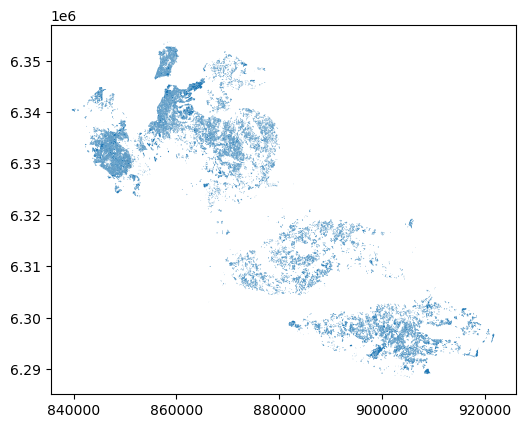

In [172]:
parcels.plot()

In [187]:
parcels_sample = parcels.sample(n=SAMPLE_SIZE,
                                random_state=RANDOM_STATE)

## Load and clip LiDAR
***
Pick a parcel of interest, dissolve any multi-row geometry, then clip the relevant LiDAR tiles to it.

In [207]:
import os
import requests
from urllib.parse import urlparse
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock, Semaphore

# Output directory
data_dir = os.path.join("..", "data")
os.makedirs(data_dir, exist_ok=True)

# Your list of URLs
urls =  lidar_file_urls(parcels_sample, zones)

data_dir = os.path.join("..", "data")
os.makedirs(data_dir, exist_ok=True)

# Rate limiter: API allows 10 req/sec per IP. We use a token-bucket-style
# semaphore that releases a slot every 0.15s, keeping us safely under the limit
# even when HEAD + GET both count as requests.
RATE_LIMIT_INTERVAL = 0.15  # seconds between request "starts"
_rate_lock = Lock()
_last_request_time = [0.0]  # mutable container so threads can update

def _rate_limit():
    """Block until enough time has passed since the last request."""
    with _rate_lock:
        now = time.monotonic()
        elapsed = now - _last_request_time[0]
        if elapsed < RATE_LIMIT_INTERVAL:
            time.sleep(RATE_LIMIT_INTERVAL - elapsed)
        _last_request_time[0] = time.monotonic()


# Thread-safe printing
_print_lock = Lock()
def safe_print(msg):
    with _print_lock:
        print(msg, flush=True)


def download_file(url, output_dir, chunk_size=8192, timeout=60, max_retries=3):
    """Download one file. Thread-safe. Returns (success, filepath, message)."""
    filename = os.path.basename(urlparse(url).path)
    filepath = os.path.join(output_dir, filename)
    
    if os.path.exists(filepath) and os.path.getsize(filepath) > 0:
        return (True, filepath, f"Already exists ({os.path.getsize(filepath) / 1e6:.1f} MB)")
    
    for attempt in range(max_retries):
        try:
            _rate_limit()
            head = requests.head(url, timeout=timeout, allow_redirects=True)
            if head.status_code == 404:
                return (False, None, "404 Not Found")
            if head.status_code >= 400:
                return (False, None, f"HTTP {head.status_code}")
            
            expected_size = int(head.headers.get('Content-Length', 0))
            
            _rate_limit()
            with requests.get(url, stream=True, timeout=timeout) as r:
                r.raise_for_status()
                
                tmp_path = filepath + ".part"
                with open(tmp_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=chunk_size):
                        if chunk:
                            f.write(chunk)
                
                actual_size = os.path.getsize(tmp_path)
                if expected_size > 0 and actual_size != expected_size:
                    os.remove(tmp_path)
                    raise IOError(f"Size mismatch: expected {expected_size}, got {actual_size}")
                
                os.rename(tmp_path, filepath)
                return (True, filepath, f"Downloaded ({actual_size / 1e6:.1f} MB)")
        
        except (requests.RequestException, IOError) as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
                continue
            return (False, None, f"Failed after {max_retries} attempts: {e}")
    
    return (False, None, "Unknown error")


def download_all(urls, output_dir, max_workers=6):
    """Download all URLs in parallel. Returns (successful_files, failed_urls)."""
    successful_files = []
    failed_urls = []
    total = len(urls)
    completed = [0]  # mutable counter for thread-safe progress
    completed_lock = Lock()
    
    def _task(url):
        result = download_file(url, output_dir)
        with completed_lock:
            completed[0] += 1
            idx = completed[0]
        filename = os.path.basename(urlparse(url).path)
        safe_print(f"[{idx}/{total}] {filename} ... {result[2]}")
        return url, result
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_task, url) for url in urls]
        for future in as_completed(futures):
            url, (success, filepath, msg) = future.result()
            if success:
                successful_files.append(filepath)
            else:
                failed_urls.append((url, msg))
    
    return successful_files, failed_urls


successful_files, failed_urls = download_all(urls, data_dir, max_workers=6)

print(f"\n=== Summary ===")
print(f"Successful: {len(successful_files)}")
print(f"Failed:     {len(failed_urls)}")
if failed_urls:
    print("\nFailed URLs:")
    for url, msg in failed_urls:
        print(f"  - {os.path.basename(urlparse(url).path)}: {msg}")

[1/37] LHD_FXX_0848_6334_PTS_LAMB93_IGN69.copc.laz ... Already exists (217.2 MB)
[2/37] LHD_FXX_0856_6340_PTS_LAMB93_IGN69.copc.laz ... Already exists (132.3 MB)
[3/37] LHD_FXX_0849_6333_PTS_LAMB93_IGN69.copc.laz ... 404 Not Found
[4/37] LHD_FXX_0844_6333_PTS_LAMB93_IGN69.copc.laz ... 404 Not Found
[5/37] LHD_FXX_0845_6333_PTS_LAMB93_IGN69.copc.laz ... 404 Not Found
[6/37] LHD_FXX_0856_6347_PTS_LAMB93_IGN69.copc.laz ... Downloaded (108.0 MB)
[7/37] LHD_FXX_0859_6349_PTS_LAMB93_IGN69.copc.laz ... Downloaded (117.3 MB)
[8/37] LHD_FXX_0859_6336_PTS_LAMB93_IGN69.copc.laz ... Downloaded (124.4 MB)
[9/37] LHD_FXX_0859_6337_PTS_LAMB93_IGN69.copc.laz ... Downloaded (115.0 MB)
[10/37] LHD_FXX_0856_6341_PTS_LAMB93_IGN69.copc.laz ... Downloaded (125.3 MB)
[11/37] LHD_FXX_0859_6350_PTS_LAMB93_IGN69.copc.laz ... Downloaded (125.7 MB)
[12/37] LHD_FXX_0858_6335_PTS_LAMB93_IGN69.copc.laz ... Downloaded (189.4 MB)
[13/37] LHD_FXX_0872_6336_PTS_LAMB93_IGN69.copc.laz ... Downloaded (205.7 MB)
[14/37] LHD

In [ ]:
import json
import pdal
import numpy as np
import laspy
from shapely import wkt as shapely_wkt

fp1 = os.path.join("..", "data", "LHD_FXX_0859_6343_PTS_LAMB93_IGN69.copc.laz")
fp2 = os.path.join("..", "data", "LHD_FXX_0859_6344_PTS_LAMB93_IGN69.copc.laz")
fp_out = os.path.join("..", "data", "clipped.laz")

SEL = parcels_dissolved.geometry.iloc[0]
sel_wkt = SEL.wkt

pipeline_json = {
    "pipeline": [
        fp1,
        fp2,
        {"type": "filters.crop", "polygon": sel_wkt},
        {"type": "filters.merge"},
        {"type": "writers.las", "filename": fp_out, "compression": "laszip"},
    ]
}

pipeline = pdal.Pipeline(json.dumps(pipeline_json))
n_points = pipeline.execute()
print(f"Wrote {n_points} points to {fp_out}")

# If you also want the arrays in memory (like the Python version produced):
arr = pipeline.arrays[0]
clipped_x = arr["X"]
clipped_y = arr["Y"]
clipped_z = arr["Z"]
classification = arr["Classification"]

In [139]:
# Define file paths for LiDAR
fp1 = os.path.join("..", "data", "LHD_FXX_0859_6343_PTS_LAMB93_IGN69.copc.laz")
fp2 = os.path.join("..", "data", "LHD_FXX_0859_6344_PTS_LAMB93_IGN69.copc.laz")

# Get the specific geometry to clip by
SEL = parcels_dissolved.geometry.iloc[0] 

lidar1 = laspy.read(fp1)
lidar2 = laspy.read(fp2)

x1, y1, z1 = np.asarray(lidar1.x), np.asarray(lidar1.y), np.asarray(lidar1.z)
x2, y2, z2 = np.asarray(lidar2.x), np.asarray(lidar2.y), np.asarray(lidar2.z)

mask1 = shapely.contains_xy(SEL, x1, y1)
mask2 = shapely.contains_xy(SEL, x2, y2)
    
clipped_x = np.concatenate([x1[mask1], x2[mask2]])
clipped_y = np.concatenate([y1[mask1], y2[mask2]])
clipped_z = np.concatenate([z1[mask1], z2[mask2]])

las_clip = laspy.create(
        point_format=lidar1.header.point_format,
        file_version=lidar1.header.version
    )

las_clip.x = clipped_x
las_clip.y = clipped_y
las_clip.z = clipped_z
las_clip.classification = np.concatenate([lidar1.classification[mask1], lidar2.classification[mask2]])

LaspyException: No LazBackend selected, cannot decompress data

## Cluster vine points
***
Group LiDAR returns into individual vines and take each cluster centroid.

In [ ]:
centroids = cluster_points(
    las_clip,
    spacing=0.73,    # max distance for points to count as the same plant
    min_points=3,
)

centroids_df = pd.DataFrame(centroids, columns=["x", "y", "z"])

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(centroids_df.x, centroids_df.y, color="#183c40", s=7)
parcels_dissolved.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_aspect("equal")
fig.set_facecolor("#f2f0e9ff")
ax.set_facecolor("#f2f0e9ff")
plt.show()

NameError: name 'las_clip' is not defined

## Detect row orientation
***
Use a 2D Fourier transform on the binned centroids to recover the dominant row angle and spacing.

In [ ]:
def find_row_orientation(data, bins=256):
    """Return (line_angle_deg, row_spacing) for a points dataframe with x, y columns."""
    hist, xedges, yedges = np.histogram2d(data["x"], data["y"], bins=bins)
    hist = hist.T

    F = np.fft.fftshift(np.fft.fft2(hist))
    magnitude = np.abs(F)

    cy, cx = np.array(magnitude.shape) // 2
    magnitude[cy, cx] = 0  # zero out DC component

    peak_y, peak_x = np.unravel_index(np.argmax(magnitude), magnitude.shape)

    dx = (xedges[-1] - xedges[0]) / bins
    dy = (yedges[-1] - yedges[0]) / bins
    fy = (peak_y - cy) / (bins * dy)
    fx = (peak_x - cx) / (bins * dx)

    line_angle = np.degrees(np.arctan2(fy, fx)) + 90  # rows are perpendicular to peak
    spacing = 1.0 / np.sqrt(fx**2 + fy**2)
    return line_angle, spacing

In [ ]:
angle_deg, row_spacing = find_row_orientation(centroids_df)
angle_deg, row_spacing

## Synthesize expected plant grid
***
Using the detected row angle and spacing, generate the lattice of plants we'd expect for a fully planted parcel.

In [ ]:
# Get Parcel Bounds
buffered_gdf = parcels_dissolved.to_crs(epsg=2154)
buffered_gdf.to_crs(epsg=2154)
buffered_gdf['geometry'] = buffered_gdf.buffer(-0.75, resolution=64)
buffered_gdf = buffered_gdf[~buffered_gdf.is_empty]

x_min, y_min, x_max, y_max = parcels_dissolved.total_bounds

# Choose your interval spacing along x
interval = 1.5  # adjust as needed
spacing = 2.5

slope = np.tan(np.radians(angle_deg))

x_mid = np.median(x_coordinates)
y_mid = np.median(y_coordinates)

# Generate points along each line
all_points = []
   
    for i in seq_y:
        # Calculate corresponding y values using y = slope * (x - x_mid) + y_intercept
        y_vals = slope * (x_vals - x_mid) + i
    
        all_points.append(np.column_stack((x_vals, y_vals)))
    
elif angle_deg > 45:
    y_vals = np.arange(y_min, y_max, interval)
    
    phase_offset = x_mid % spacing
    
    seq_x = np.arange(x_min - spacing + phase_offset, 
                      x_max + spacing, 
                      spacing)

    for i in seq_x:
        x_vals = (1 / slope) * (y_vals - y_mid) + i
    
        all_points.append(np.column_stack((x_vals, y_vals)))
        
# Combine all points into one array
all_points = np.vstack(all_points)

df = pd.DataFrame(all_points, columns=['lon', 'lat'])

points_gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs=parcels_dissolved.crs)

filtered_points = gpd.sjoin(points_gdf, buffered_gdf, predicate='within')

# Plot to verify
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(filtered_points.lon, filtered_points.lat, color='red', alpha = .5, s=5, zorder=5)

ax.scatter(x_coordinates, y_coordinates, color = '#3d5a64ff', s = 5)
#ax.scatter(las_clip.x, las_clip.y, color = '#3d5a64ff', s = 3)

parcels_dissolved.boundary.plot(ax=ax, color='black', linewidth=2)
plt.show()

## Compare actual vs expected
***
Match each expected plant to the nearest detected centroid; report the percent of expected positions that have a plant within `threshold`.

In [ ]:
expected_points = filtered_points[["lon", "lat"]].to_numpy()
actual_points = centroids_df[["x", "y"]].to_numpy()

threshold = 1.5
tree = cKDTree(actual_points)
matched = sum(1 for p in expected_points if tree.query_ball_point(p, r=threshold))

n_expected = len(expected_points)
print(f"Points With Nearby Plants: {matched}")
print(f"Total Points:              {n_expected}")
print(f"Area With Plants:          {(matched / n_expected) * 100:.2f}%")
print(f"Expected:                  {filtered_points.LVSH.iloc[0]}%")